In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import random
import numpy as np
from datetime import date

In [105]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [106]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        name = torch.cuda.get_device_name(0)
        print(f"Using GPU: {name}")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device
device = get_device()

Using GPU: NVIDIA GeForce RTX 4060


In [107]:
#lets set some hyperparameters for rnn/lstm/gru

batch_size = 264
hidden_size = 128
dropout = 0.2
num_epochs = 50
learning_rate = 0.001
clip_grad_norm = 1.0

In [108]:
# tesla_data = yf.download('TSLA', start='2020-01-01', end='2026-03-01')
# apple_data = yf.download('AAPL', start='2020-01-01', end='2026-03-01')
# tesla_data.to_csv('./data/tesla_data.csv')
# apple_data.to_csv('./data/apple_data.csv')


In [109]:
tesla_data = pd.read_csv('./data/tesla_data.csv')
apple_data = pd.read_csv('./data/apple_data.csv')

print("Tesla Data:")
print(tesla_data.head())
print("\nApple Data:")
print(apple_data.head())

Tesla Data:
         Date      Close       High        Low       Open     Volume
0  2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
1  2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2  2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
3  2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
4  2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500

Apple Data:
         Date      Close       High        Low       Open     Volume
0  2020-01-02  72.400520  72.460784  71.156682  71.409785  135480400
1  2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2  2020-01-06  72.267944  72.306514  70.568518  70.819216  118387200
3  2020-01-07  71.928062  72.533103  71.708703  72.277586  108872000
4  2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200


In [110]:
# explore the data
print(tesla_data.describe())
print(tesla_data.info())
# let's check if there is any null data 
print(tesla_data.isnull().sum())
print(apple_data.isnull().sum())


             Close         High          Low         Open        Volume
count  1547.000000  1547.000000  1547.000000  1547.000000  1.547000e+03
mean    241.968565   247.362613   236.357720   242.043730  1.194234e+08
std     100.534210   102.541549    98.585532   100.735940  7.658516e+07
min      24.081333    26.990667    23.367332    24.980000  2.940180e+07
25%     184.389999   187.409996   180.476669   184.570000  7.363565e+07
50%     237.306671   241.800003   232.600006   236.860001  9.843990e+07
75%     300.005005   307.135010   292.476669   300.024994  1.359664e+08
max     489.880005   498.829987   485.329987   489.880005  9.140820e+08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547 entries, 0 to 1546
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1547 non-null   object 
 1   Close   1547 non-null   float64
 2   High    1547 non-null   float64
 3   Low     1547 non-null   float64
 4   Open    1547 non-nu

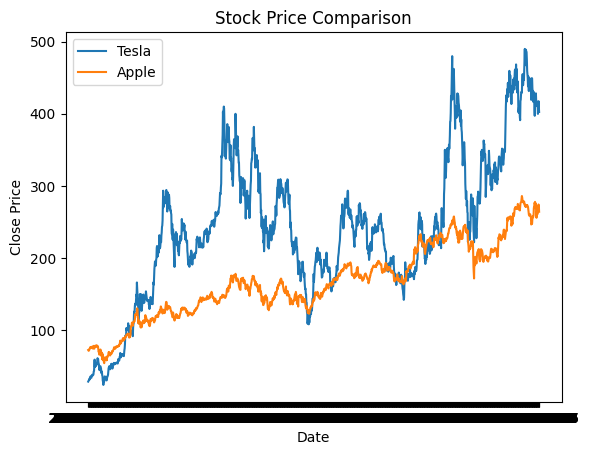

In [111]:
# lets compare the price of both stock overtime
sns.lineplot(data=tesla_data, x="Date", y="Close", label="Tesla")
sns.lineplot(data=apple_data, x="Date", y = "Close", label="Apple")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Stock Price Comparison")
plt.legend()
plt.show()


In [ ]:
# encoding the date column to datetime format
tesla_data['Date'] = pd.to_datetime(tesla_data['Date'])
apple_data['Date'] = pd.to_datetime(apple_data['Date'])
# extracting components of date
tesla_data["Year"] = tesla_data['Date'].dt.year
tesla_data["Month"] = tesla_data['Date'].dt.month
tesla_data["Day"] = tesla_data['Date'].dt.day
tesla_data["weekday"] = tesla_data['Date'].dt.weekday
tesla_data["quarter"] = tesla_data['Date'].dt.quarter
apple_data["Year"] = apple_data['Date'].dt.year
apple_data["Month"] = apple_data['Date'].dt.month
apple_data["Day"] = apple_data['Date'].dt.day
apple_data["weekday"] = apple_data['Date'].dt.weekday
apple_data["quarter"] = apple_data['Date'].dt.quarter
# cylindrical encoding of month day weekday and quarter
tesla_data["month_sin"] = np.sin(2 * np.pi * tesla_data["Month"] / 12)
tesla_data["month_cos"] = np.cos(2 * np.pi * tesla_data["Month"] / 12)
tesla_data["day_sin"] = np.sin(2 * np.pi * tesla_data["Day"] / 31)
tesla_data["day_cos"] = np.cos(2 * np.pi * tesla_data["Day"] / 31)
tesla_data["weekday_sin"] = np.sin(2 * np.pi * tesla_data["weekday"] / 7)
tesla_data["weekday_cos"] = np.cos(2 * np.pi * tesla_data["weekday"] / 7)
tesla_data["quarter_sin"] = np.sin(2 * np.pi * tesla_data["quarter"] / 4)
tesla_data["quarter_cos"] = np.cos(2 * np.pi * tesla_data["quarter"] / 4)
apple_data["month_sin"] = np.sin(2 * np.pi * apple_data["Month"] / 12)
apple_data["month_cos"] = np.cos(2 * np.pi * apple_data["Month"] / 12)
apple_data["day_sin"] = np.sin(2 * np.pi * apple_data["Day"] / 31)
apple_data["day_cos"] = np.cos(2 * np.pi * apple_data["Day"] / 31)
apple_data["weekday_sin"] = np.sin(2 * np.pi * apple_data["weekday"] / 7)
apple_data["weekday_cos"] = np.cos(2 * np.pi * apple_data["weekday"] / 7)
apple_data["quarter_sin"] = np.sin(2 * np.pi * apple_data["quarter"] / 4)
apple_data["quarter_cos"] = np.cos(2 * np.pi * apple_data["quarter"] / 4)


